### Generate Predictions using Trained Models

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import sys
import os
import time
sys.path.append(os.path.abspath(os.path.join('diffusionsim')))
import dask
import xarray as xr
import matplotlib.pyplot as plt
import gcsfs
import json
#fs = gcsfs.GCSFileSystem()

In [2]:
import diffusers
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data

In [3]:
torch.set_grad_enabled(False); print("grad enabled: ", torch.is_grad_enabled())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

grad enabled:  False


'cuda'

In [4]:
base_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "diffusion_hp_search"
run_id = "trial_1"
lettering = 'abc'

diff_logs = {}
mconfigs = []
tconfigs = []
diff_models = {}

for l in lettering:
    log_dict_path = os.path.join(base_dir, exp_id, f"{run_id}{l}.json")
    with open(log_dict_path, 'r') as file:
        diff_logs[l] = json.load(file)
    tconfigs.append(tru.TrainingConfig(**diff_logs[l]['training_config']))
    mconfigs.append(tru.ModelConfig(**diff_logs[l]['model_config']))
    model_path = os.path.join(base_dir, exp_id, "checkpoints", )
    diff_models[l] = tru.load_model_from_ckpt(f"checkpoints/best{run_id}{l}-ckpt.pt", mconfigs[-1], exp_id, base_dir).to(device)

/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/training_utils.py:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(c

In [8]:
diff_models[l].device, l

(device(type='cuda', index=0), 'c')

In [15]:
diff_logs['a']['training_config']

{'exp_id': 'diffusion_hp_search',
 'run_id': 'trial_1a',
 'num_epochs': 1,
 'phases': ['train'],
 'distributed_training': False,
 'optimizer': 'adam',
 'betas': [0.9, 0.999],
 'lr_scheduler': None,
 'learning_rate': 0.0001,
 'loss_weights': {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0},
 'clip_gradients': True,
 'max_T_sample': 51,
 'save_best_epoch': True,
 'batch_logging_interval': 32,
 'batch_checkpoint_interval': 50,
 'log_gradients': False,
 'push_to_hub': False,
 'diffusion_loss_noise_level': 10}

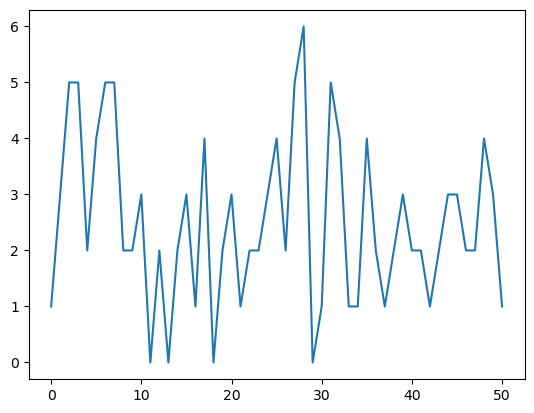

In [13]:
plt.plot(diff_logs['a']['sampled_timesteps'])


In [29]:
(train_ds, test_ds), (train_indices, test_indices) = data.load_dataset(dconfig)

In [37]:
def plot_loss(log, dataset=train_ds):
    len(log['train_loss'])
    bs, bli = dconfig.dataloader_params.batch_size, tconfig.batch_logging_interval
    plt.plot(log['train_loss'])
    batches_per_epoch = np.ceil(dataset.data.time.shape[0]  /( bs * bli))
    num_batches, num_epochs = len(log['train_loss']), tconfig.num_epochs + 1
    plt.xticks(np.arange(0, num_batches, batches_per_epoch), labels=np.arange(1, num_epochs))
    plt.title("Training Loss over time")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

In [30]:
train_ds

In [24]:
train_ds.data.time.shape[0] 

1095

In [9]:
#plot_loss(log, train_ads)

Text(0, 0.5, 'MSE Epsilon')

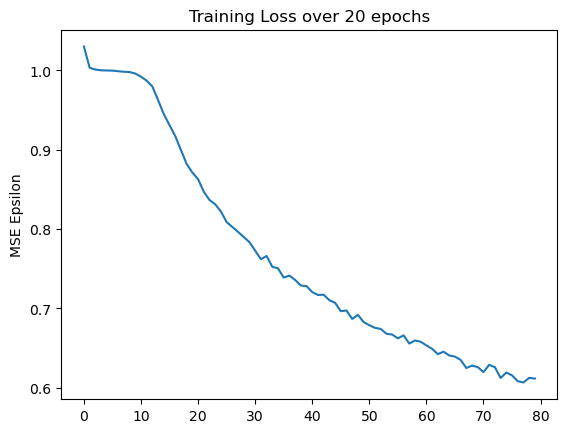

In [10]:
plt.plot(log['train_loss'])
plt.title("Training Loss over 20 epochs")
plt.ylabel("MSE Epsilon")

In [12]:
#trainer = tru.setup_trainer(exp_id, run_id, tconfig, mconfig, dconfig)
#trainer.dataloaders['train'].dataset.log = False

In [12]:
ddpm = tru.load_model_from_ckpt(f"best_{run_id}-ckpt.pt", mconfig, exp_id, base_dir).to(device)
mconfig.scheduler_type = "ddim"
scheduler = data.load_scheduler(mconfig)
ddpm.device

/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/training_utils.py:175: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cpath = os.path.join(base_dir, exp

device(type='cpu')

In [38]:
def create_sample(data, ds=train_ds):
    data = (data - ds.Ymean.mean(dim='ncol')) / ds.Ystd.mean(dim='ncol')
    data = data.isel(ncol=ds.permute_indices)
    data = data.to_stacked_array(new_dim="mlo", sample_dims=("time", "ncol"))
    data = data.transpose("time", "mlo", "ncol")
    data = torch.tensor(data.data.reshape(-1, 128, ds.height, ds.width), dtype=torch.float32)
    return data

In [39]:
def recreate_sample(sample, dataset=train_ds):
    if(isinstance(sample, torch.Tensor)):
        if(sample.device != 'cpu'):
            sample = sample.detach().cpu()
        sample = sample.numpy()
    
    xarr = xr.DataArray(sample.reshape(-1, 128, 384), dims="time mlo ncol".split(), coords=dict(
        time = np.arange(sample.shape[0]),
        mlo = dataset.mlo, 
        ncol = dataset.permute_indices
    )).isel(ncol=np.argsort(dataset.permute_indices))
    mu_stack = dataset.Ymean.to_stacked_array(new_dim="mlo", sample_dims=('ncol',))
    sig_stack = dataset.Ystd.to_stacked_array(new_dim="mlo", sample_dims=('ncol',))
    xrec = (xarr * sig_stack.mean(dim='ncol')) + mu_stack.mean(dim='ncol')
    return(xrec.transpose("time", "ncol", "mlo"))

In [40]:
# generate images
class SampleImages(torch.utils.data.IterableDataset):
    def __init__(self, ddpm, scheduler, steps=100, batch_size=1, eta=1.0):
        self.ddpm = ddpm.to(device)
        self.scheduler = scheduler
        self.set_num_images(batch_size)
        self.eta = 1.0
        # generator: Optional[Union[torch.Generator, List[torch.Generator]]] = None
        # A [`torch.Generator`](https://pytorch.org/docs/stable/generated/torch.Generator.html) make
        # generation deterministic.
        self.num_inference_steps = steps
        
    def set_num_images(self, batch_size):
        self.batch_size = batch_size
        self.image_shape = (batch_size, ddpm.config.in_channels, *ddpm.config.sample_size)

    def __iter__(self):
        # generate a batch of images
        pipeline = diffusers.DDIMPipeline(self.ddpm, self.scheduler)
        self.scheduler.set_timesteps(self.num_inference_steps)
        while(True): # can generate infinite batches      
            image = torch.randn(self.image_shape ).to(device) # could add generator=generator
            for t in pipeline.progress_bar(self.scheduler.timesteps):
                image = self._denoise(image, t)
            yield image
    
    def _denoise(self, xt, t):
        eps_theta = self.ddpm(xt, t).sample
        x_prev = self.scheduler.step(eps_theta, t, xt, eta=self.eta)
        return(x_prev.prev_sample)
        
    def encode(self, sample, t):
        eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = self.scheduler.add_noise(sample, eps, torch.LongTensor([t])) # noisy image
        return(xt, eps)
    
    def decode(self, xt, T, stride=-1, track_history=True):
        if track_history:
            history={}
            history[T-stride] = xt
        pipeline = diffusers.DDIMPipeline(self.ddpm, self.scheduler)
        for t in pipeline.progress_bar(range(T, -1, stride)): # pipe.scheduler.timesteps[-T//stride-1:]
            xt = self._denoise(xt, t)
            if track_history:
                history[t] = xt
        if track_history:
            return(history)
        return(xt)

In [16]:
pipeline_generator = SampleImages(ddpm, scheduler)

In [32]:
dataset = train_ds
dataset

## Testing Sample Recreation

In [112]:
dataset.data

<xarray.Dataset> Size: 431MB
Dimensions:         (time: 1095, lev: 60, ncol: 384)
Coordinates:
  * time            (time) object 9kB 0001-06-03 18:00:00 ... 0008-11-30 18:0...
  * ncol            (ncol) int64 3kB 0 1 2 3 4 5 6 ... 378 379 380 381 382 383
    lat             (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 40.39
    lon             (ncol) float64 3kB -39.73 -28.47 -39.56 ... 146.7 135.0
Dimensions without coordinates: lev
Data variables:
    state_t         (time, lev, ncol) float64 202MB dask.array<chunksize=(1, 60, 384), meta=np.ndarray>
    state_q0001     (time, lev, ncol) float64 202MB dask.array<chunksize=(1, 60, 384), meta=np.ndarray>
    cam_out_NETSW   (time, ncol) float64 3MB dask.array<chunksize=(1, 384), meta=np.ndarray>
    cam_out_FLWDS   (time, ncol) float64 3MB dask.array<chunksize=(1, 384), meta=np.ndarray>
    cam_out_PRECSC  (time, ncol) float64 3MB dask.array<chunksize=(1, 384), meta=np.ndarray>
    cam_out_PRECC   (time, ncol) float64 3MB dask.array<chunksize=(1, 384), meta=np.ndarray>
    cam_out_SOLS    (time, ncol) float64 3MB dask.array<chunksize=(1, 384), meta=np.ndarray>
    cam_out_SOLL    (time, ncol) float64 3MB dask.array<chunksize=(1, 384), meta=np.ndarray>
    cam_out_SOLSD   (time, ncol) float64 3MB dask.array<chunksize=(1, 384), meta=np.ndarray>
    cam_out_SOLLD   (time, ncol) float64 3MB dask.array<chunksize=(1, 384), meta=np.ndarray>

In [168]:
pipeline_generator.set_num_images(32)
image = next(iter(pipeline_generator))

  0%|          | 0/100 [00:00<?, ?it/s]

In [169]:
type(image), image.dtype, image.shape

(torch.Tensor, torch.float32, torch.Size([32, 128, 16, 24]))

(array([1.30000e+01, 4.66000e+02, 1.40060e+04, 1.78827e+05, 6.40510e+05,
        5.89600e+05, 1.39433e+05, 9.68700e+03, 3.12000e+02, 1.00000e+01]),
 array([-8.57073593, -6.83470011, -5.09866428, -3.36262798, -1.62659216,
         0.10944366,  1.84547997,  3.58151531,  5.31755161,  7.05358791,
         8.78962326]),
 <BarContainer object of 10 artists>)

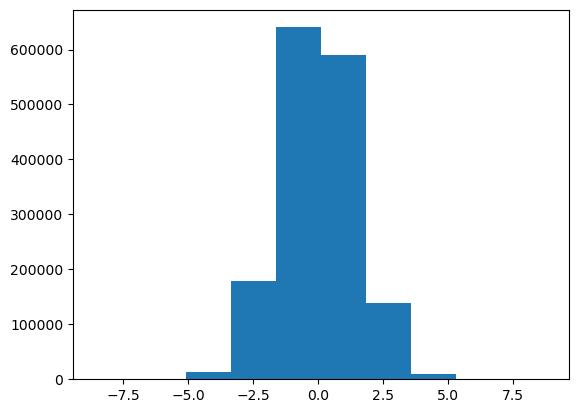

In [170]:
plt.hist(image.detach().cpu().numpy().flatten())

In [116]:
sample = dataset[0]

In [117]:
type(sample), sample.dtype, sample.shape

(torch.Tensor, torch.float32, torch.Size([32, 128, 16, 24]))

(array([3.724000e+03, 3.369920e+05, 1.224873e+06, 7.142000e+03,
        1.140000e+02, 1.200000e+01, 4.000000e+00, 2.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([-16.19524574,  -8.88400936,  -1.57277298,   5.73846245,
         13.04969978,  20.36093712,  27.67217064,  34.98340607,
         42.29464722,  49.60588074,  56.91712189]),
 <BarContainer object of 10 artists>)

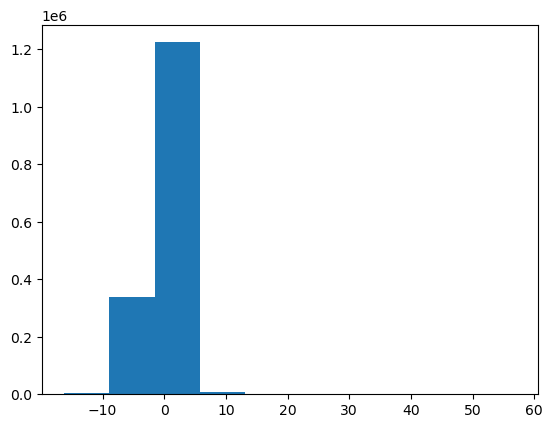

In [118]:
plt.hist(sample.numpy().flatten()) # more variance/ tails 

In [46]:
sample = recreate_sample(sample)

In [47]:
rec_image = recreate_sample(image.detach().cpu())

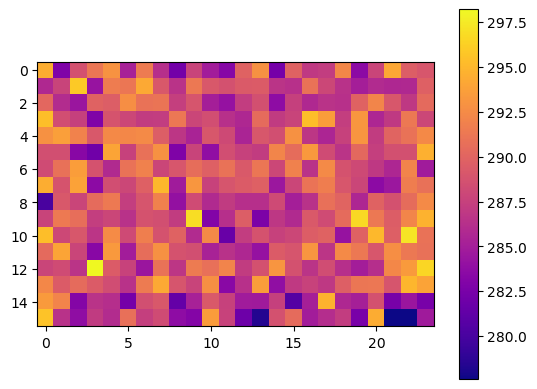

In [48]:
rec_image = recreate_sample(image.detach().cpu())
tmap = rec_image.isel(time=0, mlo=59, ncol=dataset.permute_indices).data
plt.imshow(tmap.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

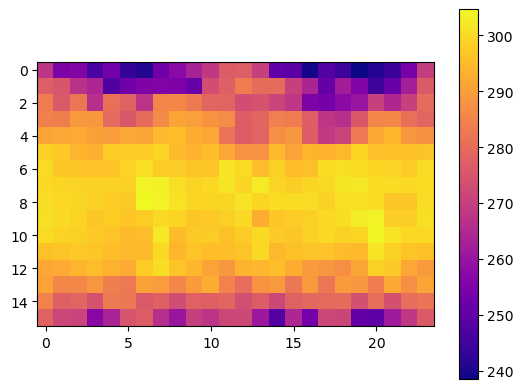

In [49]:
tmap = sample.isel(time=0, mlo=59, ncol=dataset.permute_indices).data
plt.imshow(tmap.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

In [50]:
og = dataset.data.state_t.sel(time=0, lev=59, ncol=dataset.permute_indices).load().data

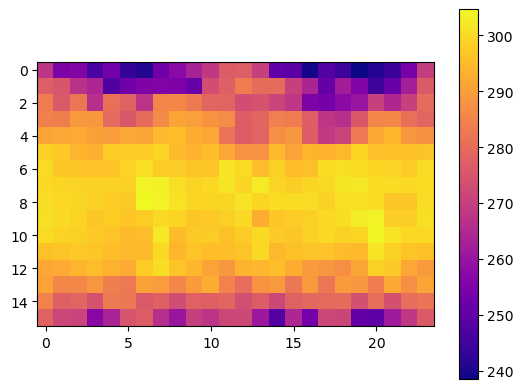

In [51]:
plt.imshow(og.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

In [55]:
print(np.isclose(tmap, og).all()) # same
(tmap - og).max()

True


np.float64(1.9781994353706978e-06)

In [30]:
ds0 = dataset.bgen[0].load()
ds0 = ds0.to_stacked_array(new_dim='mlo', sample_dims=("time", "ncol"))

In [31]:
np.isclose(sample, ds0, atol=5e-5).all()

np.True_

In [56]:
original_stderr_write = sys.stderr.write
# Define a custom stderr.write that filters out the OpenBLAS warning
def suppressed_stderr_write(message, omit='OpenBlas'):
    original_stderr_write = sys.stderr.write    
    if omit not in message:
        original_stderr_write(message)

sys.stderr.write = suppressed_stderr_write

#### testing pipeline speed

In [89]:
gen = torch.Generator()
gen

In [90]:
#os.environ['OPENBLAS_VERBOSE'] = '0'
#import warnings
#warnings.filterwarnings("ignore", category=UserWarning)

In [91]:
import time
pipeline_test = dict(sizes=[1, 2, 4, 8, 16, 32, 64, 128, 256], times=[], batches=[], device=device)

for sz in pipeline_test['sizes']:
    print(f"generating {sz} images from pipeline")
    now = time.time()
    images = pipeline(eta=0, batch_size=sz, generator=gen, num_inference_steps=50, output_type='numpy').images
    pipeline_test['times'].append(time.time() - now)
    pipeline_test['batches'].append(images)

generating 1 images from pipeline


  0%|          | 0/50 [00:00<?, ?it/s]

generating 2 images from pipeline


  0%|          | 0/50 [00:00<?, ?it/s]

generating 4 images from pipeline


...

  0%|          | 0/50 [00:00<?, ?it/s]

generating 128 images from pipeline


  0%|          | 0/50 [00:00<?, ?it/s]

generating 256 images from pipeline


  0%|          | 0/50 [00:00<?, ?it/s]

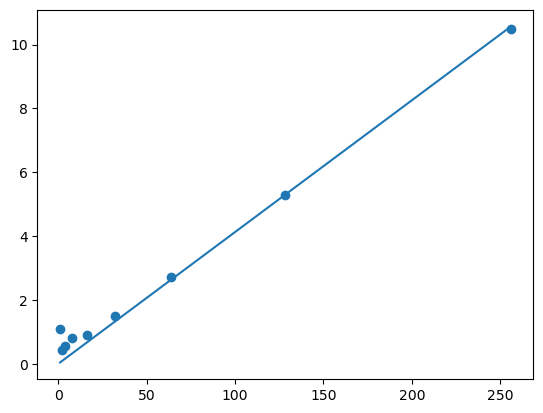

In [92]:
m, b = np.polyfit(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times'], 1)
slope = np.dot(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times']) / np.dot(pipeline_test['sizes'], pipeline_test['sizes'])

plt.scatter(pipeline_test['sizes'][:len(pipeline_test['times'])], pipeline_test['times'])
plt.plot(pipeline_test['sizes'][:len(pipeline_test['times'])], np.array(pipeline_test['sizes'][:len(pipeline_test['times'])]) * slope)


seems like batch size does not really matter for generation speed- seconds/sample stays the same. 

(array([1232349.,  745020., 1084634., 1470926., 1759822., 1759558.,
        1474366., 1084381.,  743111., 1228745.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

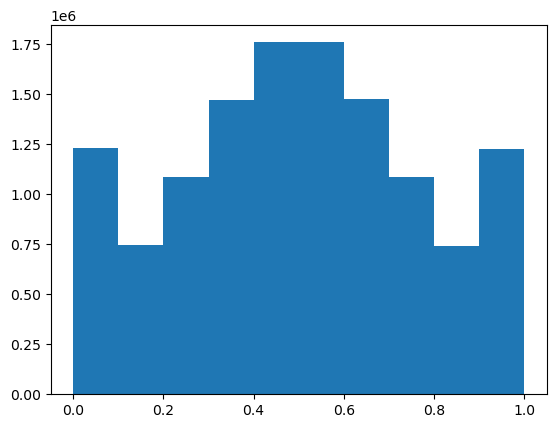

In [93]:
plt.hist(np.array(pipeline_test['batches'][-1]).flatten())

In [94]:
images = np.transpose(images, (0, 3, 1, 2))
images.shape

(256, 128, 16, 24)

In [ ]:
plt.imshow(images[0, 59])

### Comparing empirical dataset norms to saved

In [ ]:
from climsim_data_utils import data_utils, load_vars

In [ ]:
mapper = fs.get_mapper("gs://leap-persistent-ro/sungdukyu/E3SM-MMF_ne4.grid-info.zarr")
grid_info = xr.open_dataset(mapper, engine='zarr')

dutils = data_utils(grid_info=grid_info)

In [ ]:
def reconstruct_np(X_norm, Y_norm, data_vars='v1'):
    inputs, outputs = load_vars(data_vars)
    input_mean = xr.open_dataset('Climsim_info/input_mean.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    input_max = xr.open_dataset('Climsim_info/input_max.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    input_min = xr.open_dataset('Climsim_info/input_min.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values
    output_scale = xr.open_dataset('Climsim_info/output_scale.nc')[inputs].to_stacked_array('mlvar', sample_dims='').values

    X = X_norm*(input_max - input_min) + input_mean
    Y = Y_norm / output_scale
    return(X,Y)

In [ ]:
x_avg = x_npy.mean(axis=0)
x_avg.shape

In [ ]:
x_norm = xr.open_dataset("Climsim_info/input_mean.nc")

In [64]:
x_norm_v1 = x_norm[dutils.v1_inputs].to_stacked_array('mlvar', sample_dims='').values

In [75]:
(x_avg -x_norm_v1)

array([-2.56817731e-02,  4.18193672e-02,  9.98839433e-03,  6.54797630e-05,
        2.16402490e-03, -2.84236218e-03, -7.80040626e-03, -7.79458220e-04,
        6.23871345e-03,  5.40563035e-03,  2.17198329e-03,  3.37880128e-04,
       -5.97191006e-04, -9.69804839e-04,  5.85265309e-04,  1.21450536e-03,
       -3.11999986e-03, -3.44376894e-03,  5.46327227e-03,  7.97039341e-03,
        6.71671362e-03,  5.06742930e-03,  2.17408058e-03, -1.35648329e-03,
       -4.15770949e-03, -6.98711656e-03, -9.16070289e-03, -1.06326176e-02,
       -1.12655234e-02, -1.12312231e-02, -1.09699861e-02, -1.07240824e-02,
       -1.05749213e-02, -1.01690826e-02, -9.24284257e-03, -7.57338261e-03,
       -5.09230842e-03, -2.87782532e-03, -1.14609395e-03,  4.11092162e-04,
        1.60435950e-03,  2.65040335e-03,  3.15641661e-03,  3.28444663e-03,
        3.01585356e-03,  2.99826758e-03,  4.39359316e-03,  7.46977212e-03,
        1.22814718e-02,  1.88928090e-02,  2.60559371e-02,  3.35944514e-02,
        4.12411248e-02,  

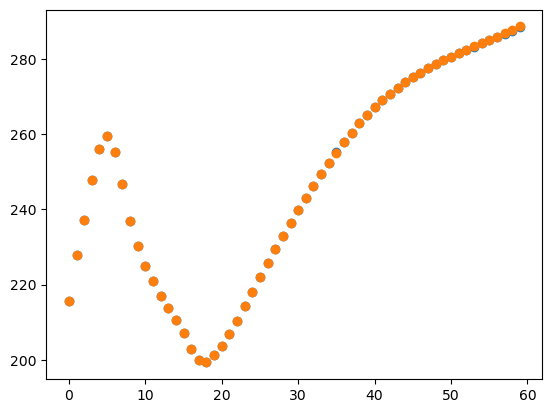

In [69]:
plt.scatter(np.arange(60), x_norm_v1[:60])
plt.scatter(np.arange(60), x_avg[:60])

In [45]:
output_scaling = xr.open_dataset("Climsim_info/output_scale.nc")

oscaling  = output_scaling[dutils.v1_outputs].to_stacked_array('mlvar', sample_dims='').values

In [52]:
y_avg = y_npy.mean(axis=0)
y_scale_test = 1./ y_avg

/tmp/ipykernel_626/3185387537.py:2: RuntimeWarning: divide by zero encountered in divide
  y_scale_test = 1./ y_avg


In [54]:
y_avg

array([ 1.19014050e-05, -1.13608688e-05, -5.22001272e-06, -1.83795208e-06,
       -1.83506310e-06,  7.04202705e-07,  1.36045056e-06,  8.66873477e-07,
        1.65614915e-08, -9.96006355e-08,  3.42032446e-07,  5.19593379e-07,
        6.27532105e-07,  6.53872793e-07,  7.57789509e-07,  1.05315910e-06,
        1.64673863e-06,  1.35920795e-06,  6.38992441e-07, -5.41416933e-07,
       -6.43335666e-09, -2.26299367e-06, -3.69347862e-06, -5.13319715e-06,
       -6.32380659e-06, -6.27994870e-06, -5.32568580e-06, -4.25518677e-06,
       -3.33941632e-06, -2.52159343e-06, -1.73624515e-06, -1.34164169e-06,
       -6.12715034e-07,  1.00480138e-07,  6.40130091e-07,  8.57316853e-07,
        1.44235977e-06,  1.70224506e-06,  1.48805081e-06,  1.39098697e-06,
        1.65367745e-06,  2.02146425e-06,  1.71443179e-06,  1.11403501e-06,
        1.36902466e-06,  1.54391288e-06,  2.10816170e-06,  3.53536307e-06,
        4.23332185e-06,  5.19102267e-06,  4.95795627e-06,  6.65066905e-06,
        7.07406187e-06,  

In [53]:
y_scale_test

array([ 8.40236928e+04, -8.80214374e+04, -1.91570414e+05, -5.44083826e+05,
       -5.44940390e+05,  1.42004567e+06,  7.35050598e+05,  1.15357088e+06,
        6.03810352e+07, -1.00400966e+07,  2.92369923e+06,  1.92458187e+06,
        1.59354397e+06,  1.52934945e+06,  1.31962767e+06,  9.49524147e+05,
        6.07260911e+05,  7.35722592e+05,  1.56496374e+06, -1.84700540e+06,
       -1.55439851e+08, -4.41892530e+05, -2.70747472e+05, -1.94810363e+05,
       -1.58132604e+05, -1.59236969e+05, -1.87769245e+05, -2.35007311e+05,
       -2.99453528e+05, -3.96574637e+05, -5.75955532e+05, -7.45355490e+05,
       -1.63208008e+06,  9.95221566e+06,  1.56218246e+06,  1.16642989e+06,
        6.93308299e+05,  5.87459482e+05,  6.72020063e+05,  7.18913996e+05,
        6.04712847e+05,  4.94690916e+05,  5.83283632e+05,  8.97637854e+05,
        7.30447030e+05,  6.47704940e+05,  4.74346915e+05,  2.82856380e+05,
        2.36221113e+05,  1.92640268e+05,  2.01696010e+05,  1.50360812e+05,
        1.41361500e+05,  

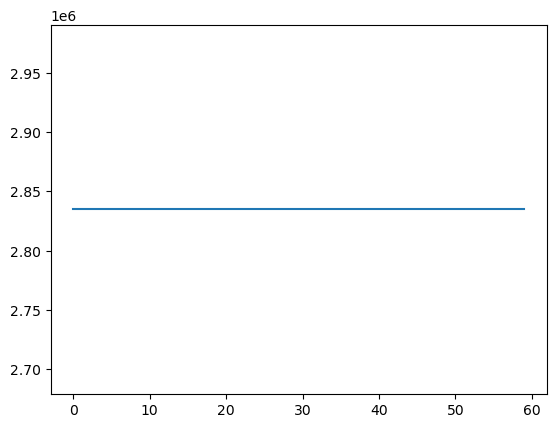

In [56]:
plt.plot(np.arange(60), oscaling[60:120])
#plt.plot(np.arange(60), y_scale_test[60:120])

In [33]:
oscaling.values()

ValuesView(<xarray.Dataset> Size: 1kB
Dimensions:         (lev: 60)
Dimensions without coordinates: lev
Data variables:
    ptend_t         (lev) float64 480B ...
    ptend_q0001     (lev) float64 480B ...
    cam_out_NETSW   float64 8B ...
    cam_out_FLWDS   float64 8B ...
    cam_out_PRECSC  float64 8B ...
    cam_out_PRECC   float64 8B ...
    cam_out_SOLS    float64 8B ...
    cam_out_SOLL    float64 8B ...
    cam_out_SOLSD   float64 8B ...
    cam_out_SOLLD   float64 8B ...)

# Image Metrics

In [19]:
pipeline_generator.set_num_images(32)
dimages = next(iter(pipeline_generator))

  0%|          | 0/100 [00:00<?, ?it/s]

In [20]:
images = train_ds[0]

In [21]:
images.shape

torch.Size([32, 128, 16, 24])

### SSIM

In [22]:
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM

In [90]:
ssim = SSIM(data_range=1.0).to(device)

In [92]:
sssim = SSIM(data_range=1.0)

In [94]:
%%time
sssim(images, dimages.detach().cpu())

CPU times: user 1.24 s, sys: 188 ms, total: 1.43 s
Wall time: 228 ms


tensor(0.0051)

In [87]:
dimages.device

device(type='cuda', index=0)

In [88]:
device

'cuda'

In [95]:
%%time
ssim(images.to(device), dimages)

CPU times: user 3.33 ms, sys: 143 µs, total: 3.48 ms
Wall time: 3.18 ms


tensor(0.0051, device='cuda:0')

## Spectral

In [24]:
dim_ftt = torch.fft.fft(dimages)

In [33]:
dim_ftt.shape, dimages.shape

mag, phase = torch.abs(dim_ftt), torch.angle(dim_ftt) 

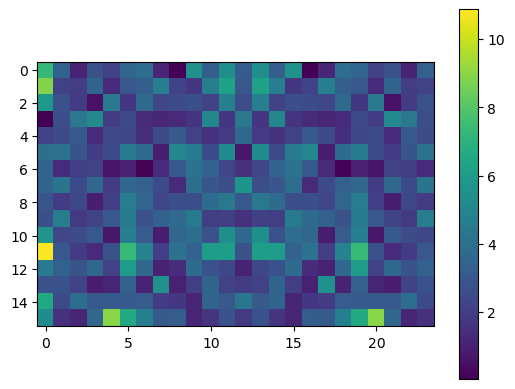

In [40]:
plt.imshow(mag[0][59].detach().cpu().numpy())
plt.colorbar()
plt.show()

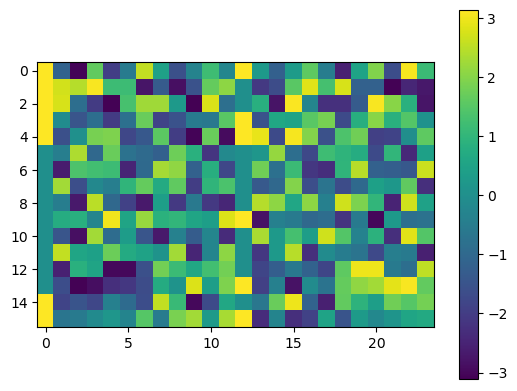

In [39]:
plt.imshow(phase[0][59].detach().cpu().numpy())
plt.colorbar()
plt.show()

# Evaluating

Ok so we have a diffusion model... is it any good?

In [56]:
from ipywidgets import interact, widgets

In [33]:
num_images = 10
def get_random_images(num_images, ds):     
    indices = np.random.randint(0, ds.time.size, size=num_images)
    item = ds.isel(time=indices).load()
    return( create_sample(item) , indices )

In [41]:
real_images, idxs = get_random_images(100, dataset.data)

In [18]:
pipeline = diffusers.DDIMPipeline(ddpm, scheduler)

[Check Pipeline Source Code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/pipelines/ddim/pipeline_ddim.py)

### Test 0: Inspecting Generated Images

In [20]:
dsi, dso = diff.climsim_utils.load_raw_dataset(dconfig)

In [21]:
dso.sizes

Frozen({'time': 10952, 'lev': 60, 'ncol': 384})

(array([1.555500e+04, 3.600684e+06, 1.298322e+06, 5.780000e+02,
        5.200000e+01, 6.000000e+00, 1.000000e+00, 0.000000e+00,
        1.000000e+00, 1.000000e+00]),
 array([-17.2358284 ,  -8.02222061,   1.19138718,  10.40499496,
         19.61860275,  28.83221054,  38.04581833,  47.25942612,
         56.47303391,  65.68664551,  74.90024567]),
 <BarContainer object of 10 artists>)

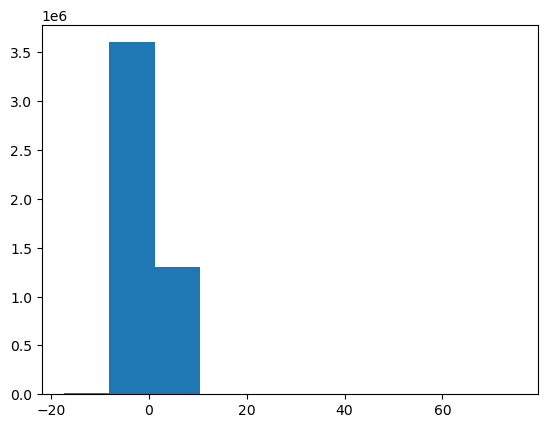

In [24]:
plt.hist(real_images.flatten())

In [25]:
pipeline_generator.set_num_images(10)
gen = iter(pipeline_generator)

In [26]:
fake_images = next(gen)

  0%|          | 0/100 [00:00<?, ?it/s]

In [27]:
fake_images.shape

torch.Size([10, 128, 16, 24])

In [28]:
faked_images = recreate_sample(fake_images)

In [29]:
faked_images.sizes

Frozen({'time': 10, 'ncol': 384, 'mlo': 128})

In [58]:


def interactive_image_viewer(images, cmap='viridis', dataset=train_ds):
    """
    Interactive viewer to display a 2D slice from a 4D array of images.
    
    Parameters:
    images (np.ndarray): A numpy array of shape (100, 128, 16, 24), representing 100 sets of maps,
                         each containing 128 variables, each of size 16x24.
    """
    # Define interactive plot function
    def plot_image(index, variable):
        vmap = images.isel(time=index, mlo=variable, ncol=dataset.permute_indices).data
        plt.imshow(vmap.reshape(16,24), cmap=cmap)
        plt.colorbar()
        plt.title(f"Image {index + 1} - Variable {dataset.mlo[variable].item()}")
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = images.time.size, images.mlo.size
    index_slider = widgets.IntSlider(value=0, min=0, max=n-1, step=1, description='Index:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    
    # Display interactive plot
    interact(plot_image, index=index_slider, variable=variable_slider)

# Example usage:
# images = np.random.rand(100, 128, 16, 24) # Replace with your actual data
interactive_image_viewer(faked_images)

interactive(children=(IntSlider(value=0, description='Index:', max=9), IntSlider(value=0, description='Variabl…

### Test One: Using DDPM as Encoder-Decoder
Let's imagine $x_{in} \in \mathbb{R}^{C \times H \times W}$ is the output of your ML emulator. I want to perturb $x$ to a noisy sample $z_t$; the larger the t, the further away I am taking from the image manifold before denoising back. 



Encoding: Noising a sample $$x_t(x_0, \epsilon) = \sqrt{\bar{\alpha_t}} \cdot x_0 + \sqrt{1-\bar{\alpha_t}} \cdot \epsilon$$

Decoding: De-Noising it and bring it closer to distribution
$$\epsilon_{\theta} = DDPM(z_t, t)$$
$$x_{t-1} \sim p_{\theta}(x_{t-1}|x_t) = \dfrac{1}{\sqrt{\alpha_t}}\left( x_t - \dfrac{\beta_t}{\sqrt{1-\bar{\alpha_t}}}\epsilon_{\theta}\right) + \sigma_t z, z\sim \mathcal{N}(0, 1)$$


In [19]:
scheduler.set_timesteps(100)

In [42]:
real_images.shape

torch.Size([100, 128, 16, 24])

Text(0.5, 1.0, 'Surface Temp')

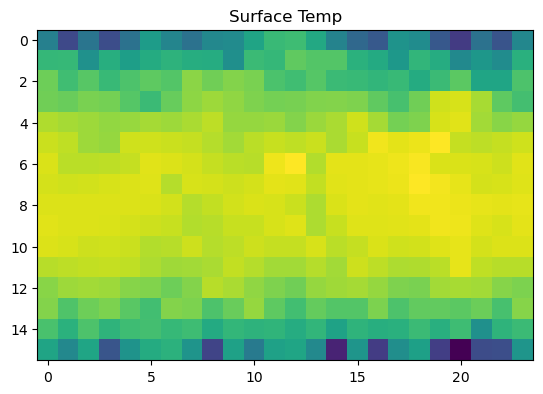

In [43]:
plt.imshow(real_images[0, 59])
plt.title("Surface Temp")

In [65]:
x_noisy, eps = pipeline_generator.encode(real_images.to(device), 99)

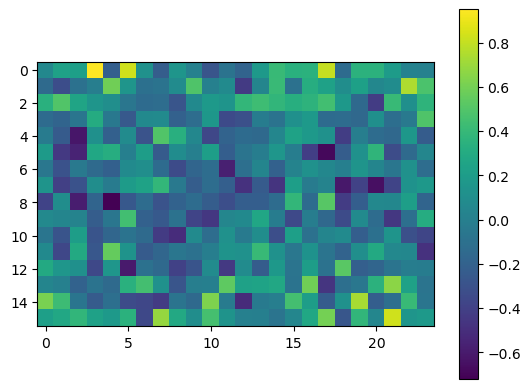

In [45]:
plt.imshow((x_noisy.detach().cpu() - real_images)[0, 59])
plt.colorbar()

Text(0.5, 1.0, 'Surface Temp, noisy')

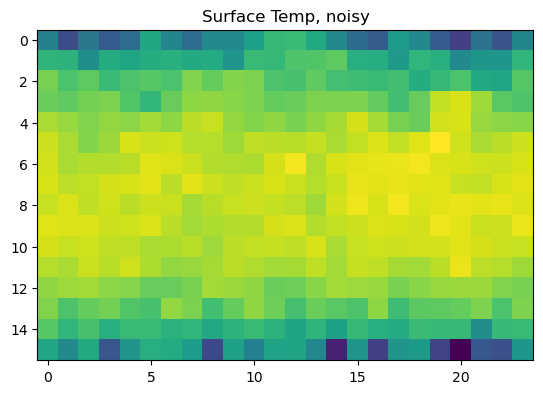

In [46]:
plt.imshow(x_noisy.detach().cpu()[0, 59])
plt.title("Surface Temp, noisy")

In [66]:
history = pipeline_generator.decode(x_noisy, 10)

  0%|          | 0/11 [00:00<?, ?it/s]

In [48]:
history.keys()

dict_keys([26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

(array([1.880000e+02, 2.468300e+04, 1.026991e+06, 3.746263e+06,
        1.164680e+05, 5.380000e+02, 5.000000e+01, 1.800000e+01,
        0.000000e+00, 1.000000e+00]),
 array([-12.15067863,  -8.44367695,  -4.73667479,  -1.02967262,
          2.67732906,   6.38433075,  10.09133339,  13.79833412,
         17.50533676,  21.2123394 ,  24.91934013]),
 <BarContainer object of 10 artists>)

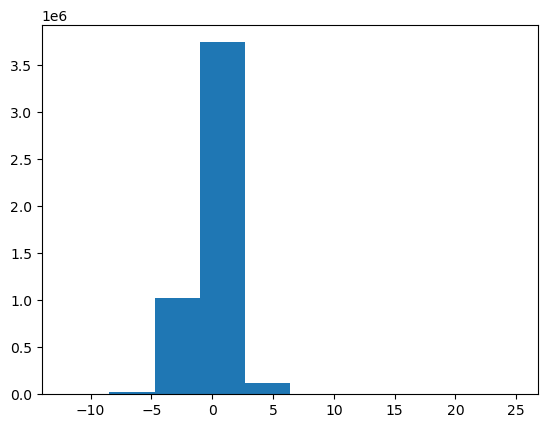

In [72]:

t = 4

plt.hist(history[t].flatten())

In [58]:
def plot_histogram_evolution(history):
    def plot_timestep(t):
        plt.figure(figsize=(10, 6))
        plt.hist(history[t].flatten(), bins=50, density=True)
        plt.title(f'Distribution at Denoising Step {t}')
        plt.xlabel('Values')
        plt.ylabel('Density')
        plt.grid(True)
        plt.show()
    
    # Create slider for time steps
    t_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max(history.keys()),
        step=1,
        description='Time Step:',
        continuous_update=False
    )
    
    # Display interactive plot
    interact(plot_timestep, t=t_slider)

plot_histogram_evolution(history)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Step:', max=26), Output())…

(array([9.330000e+02, 7.479300e+04, 2.689584e+06, 2.143850e+06,
        5.753000e+03, 2.400000e+02, 3.300000e+01, 1.200000e+01,
        1.000000e+00, 1.000000e+00]),
 array([-17.26376343, -11.40318298,  -5.54260349,   0.317976  ,
          6.17855644,  12.03913689,  17.89971542,  23.76029587,
         29.62087631,  35.48145676,  41.3420372 ]),
 <BarContainer object of 10 artists>)

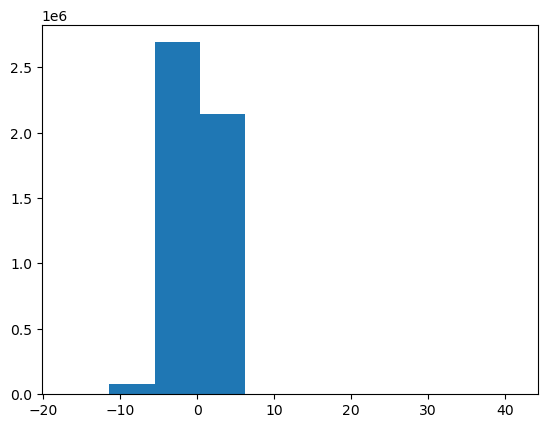

In [61]:
plt.hist(real_images.flatten())

In [62]:
fake_images = next(iter(pipeline_generator))

  0%|          | 0/100 [00:00<?, ?it/s]

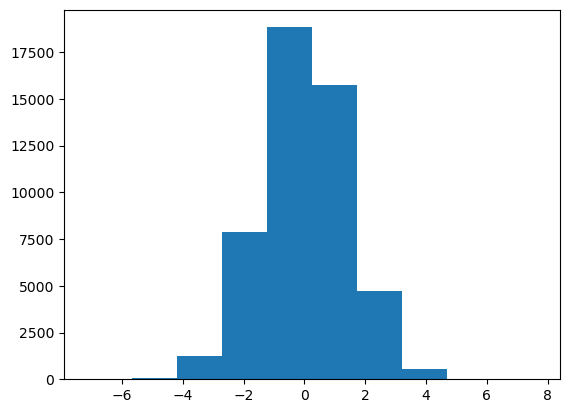

In [63]:
plt.hist(fake_images.flatten())
plt.show()

In [73]:
history[5].device, history[5].shape

(device(type='cuda', index=0), torch.Size([100, 128, 16, 24]))

In [97]:
rec_images = recreate_sample(history[5])

In [76]:
rec_images

<xarray.DataArray (time: 100, ncol: 384, mlo: 128)> Size: 39MB
array([[[ 2.12406178e+02,  2.32684557e+02,  2.37165173e+02, ...,
          1.59283310e+02,  6.79641043e+01,  2.02156690e+01],
        [ 2.10451559e+02,  2.23983640e+02,  2.30077563e+02, ...,
          1.62461238e+02,  7.52655094e+01,  5.48287911e+01],
        [ 2.07903022e+02,  2.28322933e+02,  2.34790736e+02, ...,
          1.43463297e+02,  7.65161789e+01,  5.76651281e+01],
        ...,
        [ 2.15742982e+02,  2.19399871e+02,  2.31538549e+02, ...,
         -4.98357643e+00,  2.18163861e+01,  3.77847361e+00],
        [ 2.16034548e+02,  2.21952082e+02,  2.33479653e+02, ...,
         -2.12041146e+01, -4.92325025e-01, -4.77472680e-01],
        [ 2.12884749e+02,  2.19395437e+02,  2.29871887e+02, ...,
         -8.25885685e+00, -5.37821502e+00,  9.08801158e+00]],

       [[ 2.12005127e+02,  2.07198246e+02,  2.27522324e+02, ...,
          2.74440246e+02,  1.19352002e+02,  9.64142722e+01],
        [ 2.14251210e+02,  2.17020550e+02,  2.31438562e+02, ...,
          3.16426402e+02,  1.40633525e+02,  8.35820290e+01],
        [ 2.05453724e+02,  2.07109969e+02,  2.31092284e+02, ...,
          1.21733475e+02,  1.16326864e+02,  1.15267531e+02],
...
        [ 2.19399611e+02,  2.32632088e+02,  2.47162589e+02, ...,
         -8.30539086e-02, -1.31459531e+01, -2.62645682e-01],
        [ 2.14867430e+02,  2.37009235e+02,  2.48041695e+02, ...,
         -4.54446399e+00, -5.31819268e+00, -1.72149606e+00],
        [ 2.18314307e+02,  2.37214819e+02,  2.40955557e+02, ...,
          4.14191129e+01, -1.78210897e+01, -1.50394191e+01]],

       [[ 2.13914299e+02,  2.21614054e+02,  2.38728417e+02, ...,
          3.47773679e+01,  1.13071576e+02,  7.73183953e+01],
        [ 2.17665508e+02,  2.28034206e+02,  2.36220633e+02, ...,
          2.57665437e+02,  1.42392045e+02,  7.97725508e+01],
        [ 2.13445839e+02,  2.22133129e+02,  2.35114329e+02, ...,
          1.29766232e+02,  1.20844691e+02,  7.03221071e+01],
        ...,
        [ 2.16718160e+02,  2.31616553e+02,  2.40888437e+02, ...,
         -6.94123329e+00,  6.22169490e+00,  4.56462253e+00],
        [ 2.20682148e+02,  2.30656279e+02,  2.30441014e+02, ...,
          4.76529109e+01,  8.89538716e+00,  3.41576744e+00],
        [ 2.22544052e+02,  2.33096341e+02,  2.34209410e+02, ...,
          1.00009088e+01, -2.81044645e+01, -2.46503176e+01]]])
Coordinates:
  * time      (time) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
  * mlo       (mlo) object 1kB MultiIndex
  * variable  (mlo) object 1kB 'state_t' 'state_t' ... 'cam_out_SOLLD'
  * lev       (mlo) object 1kB 0 1 2 3 4 5 6 7 ... nan nan nan nan nan nan nan
  * ncol      (ncol) int64 3kB 0 1 2 3 4 5 6 7 ... 377 378 379 380 381 382 383

In [104]:
real_images.shape

torch.Size([100, 128, 16, 24])

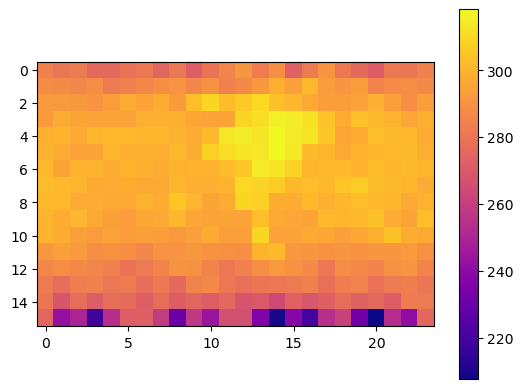

In [98]:
recreate_sample(history[5])
data = rec_images.isel(time=0, mlo=[59, 28], ncol=dataset.permute_indices).data
temp_map = data[:, 0] # mlvar 59 is temperature
humidity_map = data[:, 1] # mlvar 28 is temperature
plt.imshow(temp_map.reshape(16, 24), cmap='plasma')
plt.colorbar()
plt.show()

In [71]:
max(history.keys())

26

In [99]:
def plot_denoising_history_old(history):
    images_to_show = []
    for t in range(T, 0, stride):
        images_to_show.append((t, recreate_sample(history[t].detach().cpu())))
    images_to_show.append((t, recreate_sample(history[0].detach().cpu())))
    # Set up the figure for displaying images
    fig, axes = plt.subplots(len(mlvars), len(images_to_show), figsize=(len(images_to_show) * 5, 5))
    plt.subplots_adjust(wspace=0, hspace=0)
    # Plot each image in the carousel
    for var_idx, mlvar in enumerate(mlvars):
        for img_idx, (t, img) in enumerate(images_to_show):
            variable_map = img.isel(time=idx, mlo=mlvar, ncol=dataset.permute_indices).data.reshape(16, 24)
            axes[var_idx, img_idx].imshow(variable_map, cmap='plasma')
            axes[var_idx, img_idx].axis('off')
            axes[var_idx, img_idx].set_title(f'{dataset.mlo[mlvar].item()}, t={t}')
    plt.tight_layout()
    plt.show()
    #return(images_to_show)

def denoising_history(history, cmap='plasma', dataset=train_ds):
    # Define interactive plot function
    def plot_image(index, variable, denoise_step):
        vmap = recreate_sample(history[denoise_step]).isel(time=index, mlo=variable, ncol=dataset.permute_indices).data
        plt.imshow(vmap.reshape(16,24), cmap=cmap)
        plt.colorbar()
        plt.title(f"Image {index + 1} - Variable {dataset.mlo[variable].item()}")
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = history[0].shape[:2]
    index_slider = widgets.IntSlider(value=0, min=0, max=n-1, step=1, description='Index:')
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    noise_slider = widgets.IntSlider(value=0, min=0, max=max(history.keys()), step=1, description='Denoising step:')
    # Display interactive plot
    interact(plot_image, index=index_slider, variable=variable_slider, denoise_step=noise_slider)


In [101]:
denoising_history(history)

interactive(children=(IntSlider(value=0, description='Index:', max=99), IntSlider(value=0, description='Variab…

In [72]:
history.keys()

dict_keys([26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

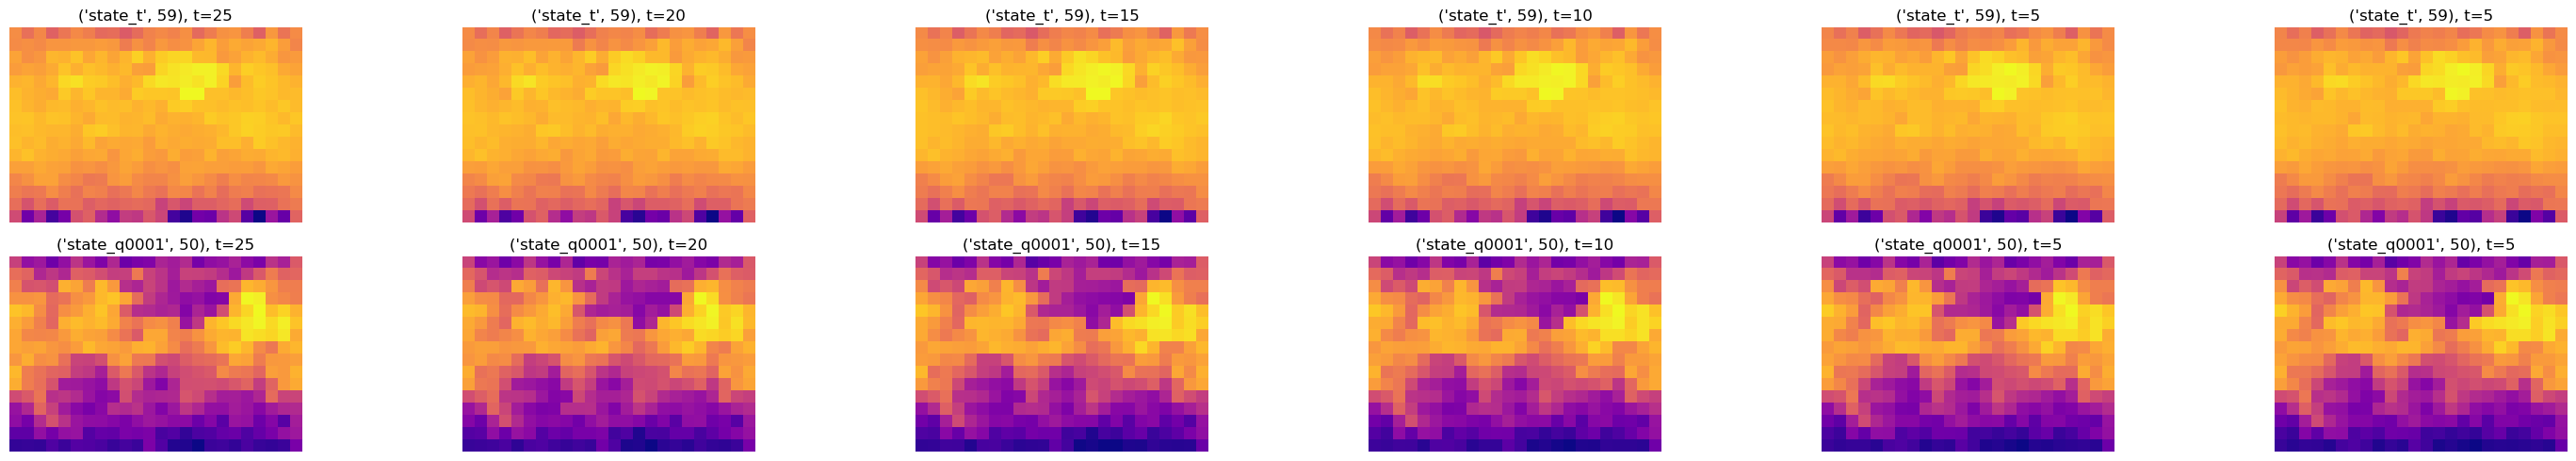

In [71]:
plot_denoising_carousel(history, 25, stride=-5, idx=0, mlvars=[59, 110])

In [51]:
mlvars, idx = [59, 110], 0

In [43]:
list(enumerate(mlvars))

[(0, 59), (1, 110)]

In [122]:
#data = images_to_show[0].isel(time=0, mlo=59, ncol=train_ds.permute_indices).data

In [124]:
#fig, axes = plt.subplots(1, 5, figsize=(5 * 5, 5))
#axes[0, 0].plot([1, 2, 3], [1, 2, 4])
#axes

In [125]:
#imgs = plot_denoising_carousel(history, 25, stride=-5, idx=0, mlvars=[59, 110])

In [37]:
def encode(sample, t):
    eps = torch.randn(sample.shape, device=device) # BS x C x H x W
    xt = scheduler.add_noise(sample, eps, torch.LongTensor([t])) # noisy image
    return(xt, eps)

In [38]:
def decode(xt, T, unet=ddpm, scheduler=scheduler, track_history=True):
    if track_history:
        history = {T : xt}
    for t in range(T, 0, -1): # pipe.scheduler.timesteps[-T//stride-1:]
        with torch.no_grad():
            eps_theta = unet(xt, t).sample
        x_prev = scheduler.step(eps_theta, t, xt)
        xt = x_prev.prev_sample
        if track_history:
            history[t-1] = xt
    return(xt, history)

In [33]:
print(real_images.shape)
dataset[5].shape


torch.Size([100, 128, 16, 24])


torch.Size([32, 128, 16, 24])

In [41]:
def encode_decode_dists(dataset, index, T, unet=ddpm, scheduler=scheduler, pure_noise=False, verbose=False):
    start = time.time()
    if pure_noise:
        x0 = torch.randn(dataset[index].shape, device=device)
    else:
        x0 = dataset[index].to(device)
    
    if(verbose):
        print(f"Loaded item after {time.time() - start} seconds; denoising to step {T}")
    distances = []
    dist = torch.nn.MSELoss()
    for t in range(T):
        xt, eps = encode(x0, t)
        distances.append(dist(x0, xt).item())

    for t in range(T, 0, -1): # pipe.scheduler.timesteps[-T//stride-1:]
        with torch.no_grad():
            eps_theta = unet(xt, t).sample
        x_prev = scheduler.step(eps_theta, t, xt)
        xt = x_prev.prev_sample
        distances.append(dist(x0, xt).item())
    return(np.array(distances))

In [35]:
print(len(train_ds))
num_batches = 5
indices = torch.randint(0, len(train_ds), (num_batches,))
indices

34


tensor([29,  0,  5, 26, 23])

In [42]:
Ts = [10, 25, 50]
data = {}
for T in Ts:
    data[T] = encode_decode_dists(train_ds, int(indices[0]), T, pure_noise=True, verbose=True)
    for index in indices[1:]:
        data[T] += encode_decode_dists(train_ds, int(index), T, pure_noise=True, verbose=True)

Loaded item after 0.5676259994506836 seconds; denoising to step 10
Loaded item after 1.1416215896606445 seconds; denoising to step 10
Loaded item after 0.549081563949585 seconds; denoising to step 10
Loaded item after 1.1466169357299805 seconds; denoising to step 10
Loaded item after 1.1339874267578125 seconds; denoising to step 10
Loaded item after 0.5533618927001953 seconds; denoising to step 25
Loaded item after 0.5574345588684082 seconds; denoising to step 25
Loaded item after 0.5495984554290771 seconds; denoising to step 25
Loaded item after 0.5496015548706055 seconds; denoising to step 25
Loaded item after 0.744823694229126 seconds; denoising to step 25
Loaded item after 0.555823802947998 seconds; denoising to step 50
Loaded item after 0.5468237400054932 seconds; denoising to step 50
Loaded item after 0.54469895362854 seconds; denoising to step 50
Loaded item after 0.5860390663146973 seconds; denoising to step 50
Loaded item after 0.7336890697479248 seconds; denoising to step 50


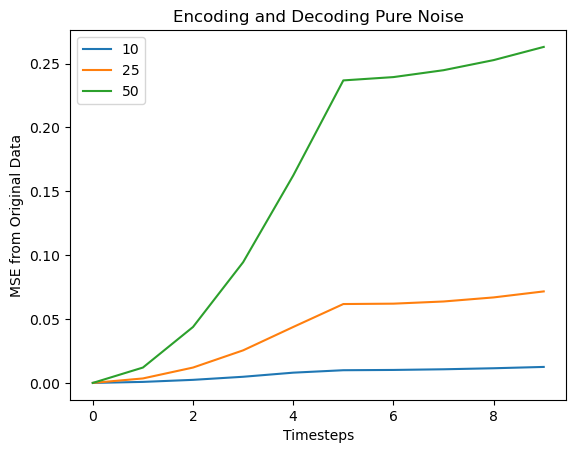

In [44]:
plt.plot(data[10][::2], label=10)
plt.plot(data[25][::5], label=25)
plt.plot(data[50][::10], label=50)
plt.legend()
plt.title(f"Encoding and Decoding Pure Noise")
plt.ylabel("MSE from Original Data")
plt.xlabel("Timesteps")
plt.show()

In [156]:
Ts = [10, 25, 50]
data = {}
for T in Ts:
    data[T] = encode_decode_dists(train_ds, int(indices[0]), T, verbose=True)
    for index in indices[1:]:
        data[T] += encode_decode_dists(train_ds, int(index), T, verbose=True)

Loaded item after 0.621530294418335 seconds; denoising to step 10
Loaded item after 1.1254692077636719 seconds; denoising to step 10
Loaded item after 1.1418592929840088 seconds; denoising to step 10
Loaded item after 1.1139025688171387 seconds; denoising to step 10
Loaded item after 1.14725923538208 seconds; denoising to step 10
Loaded item after 0.5982179641723633 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.5726149082183838 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.5611705780029297 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.5395488739013672 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.559136152267456 seconds; denoising to step 25
Decoded to step  25
Loaded item after 0.5664746761322021 seconds; denoising to step 50
Decoded to step  50
Decoded to step  25
Loaded item after 0.777012825012207 seconds; denoising to step 50
Decoded to step  50
Decoded to step  25
Loaded item after 0.5

In [159]:
for key, value in data.items():
    data[key] = value / len(indices)

In [161]:
data[10]

array([0.00010001, 0.00040108, 0.00090285, 0.00160852, 0.00251562,
       0.00362387, 0.00493786, 0.00645424, 0.00817317, 0.01011272,
       0.00975462, 0.00944947, 0.00919356, 0.00898288, 0.00881219,
       0.00867608, 0.0085698 , 0.00848928, 0.00843116, 0.00839389])

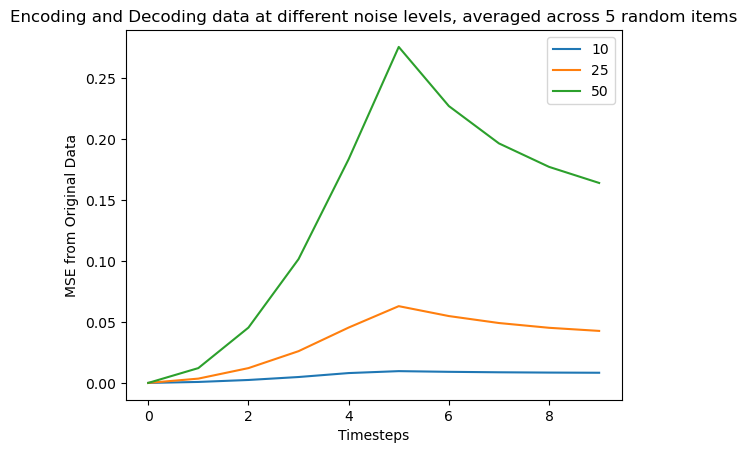

In [163]:
plt.plot(data[10][::2], label=10)
plt.plot(data[25][::5], label=25)
plt.plot(data[50][::10], label=50)
plt.legend()
plt.title(f"Encoding and Decoding data at different noise levels, averaged across {len(indices)} random items")
plt.ylabel("MSE from Original Data")
plt.xlabel("Timesteps")
plt.show()

In [120]:
for key, value in data.items():
    data[key] = list(value)

In [121]:
with open("images/ED_difftest.json", 'w') as file:
    json.dump(data, file)

In [112]:
data[25]

array([0.00010004, 0.00040101, 0.00090381, 0.00160752, 0.0025139 ,
       0.00362368, 0.00493781, 0.00646016, 0.00817705, 0.01011331,
       0.00920108, 0.00841366, 0.00774693, 0.00719623, 0.00675461,
       0.00641415, 0.00616434, 0.00599223, 0.00588539, 0.00582726])

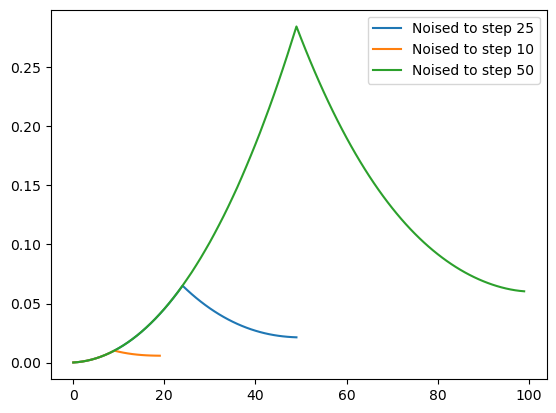

In [106]:
for t in data.keys():
    plt.plot(data[t], label=f'Noised to step {t}')

plt.legend()
plt.show()

In [104]:
encode_decode_dists(train_ds, 64, 99, verbose=True)

KeyboardInterrupt: 

In [102]:
for t in [99]:
    print("At time ", t)
    distances = 0
    for index in torch.randint(0, len(train_ds), (num_batches,)).numpy():
        print(index, end=" ")
        distances = distances + encode_decode_dists(train_ds, int(index), t)

    data[t] = distances / num_batches



At time  99
62 

KeyboardInterrupt: 

In [75]:
ds = encode_decode_dists(train_ds, 83, 25)

Loaded item after 13.758191585540771 seconds


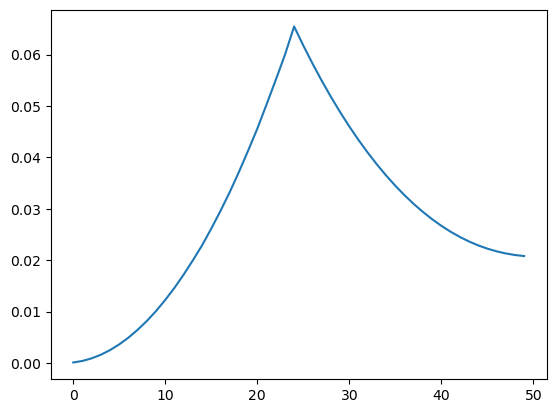

In [65]:
plt.plot(ds)

In [59]:
%%time
item = train_ds[26]

CPU times: user 10.4 s, sys: 7.34 s, total: 17.7 s
Wall time: 14.1 s


In [26]:
item.shape

torch.Size([32, 128, 16, 24])

In [27]:
x25, eps = encode(item.to(device), 25)

In [28]:
x0_hat, history25 = decode(x25, 25)

In [44]:
dist = torch.nn.MSELoss()
history25['diffs'] = []
for t in list(history25.keys()):
    if isinstance(t, int):
        history25['diffs'].append(dist(item.to(device), history25[t]).item())

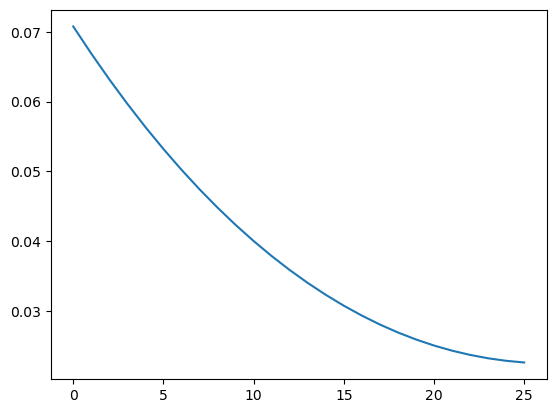

In [48]:
#plt.plot(history['diffs'])
plt.plot(history25['diffs'])

#### How it works

In [40]:
t = 25

In [41]:
zt, eps = encode(item, 25)

In [52]:
zt.shape

torch.Size([128, 128, 16, 24])

In [48]:
at = scheduler.alphas_cumprod[t]
zt_manual = torch.sqrt(at) * item + torch.sqrt(1-at)*eps

(zt_manual == zt).all().item()

True

In [55]:
with torch.no_grad():
    eps_theta = ddpm(zt.to(device), torch.tensor([25], device=device))

In [97]:
x24 = ddim_scheduler.step(eps_theta.sample, 25, zt.to(device)).prev_sample

In [98]:
x24.shape

torch.Size([128, 128, 16, 24])

In [86]:
a24 = ddim_scheduler.alphas_cumprod[24]
a25 = ddim_scheduler.alphas_cumprod[25]

DDIM Sampling:
$$x_{t-1} = \sqrt{\alpha_{t-1}}\left( \dfrac{x_t - \sqrt{1-\alpha_t} \epsilon_\theta}{\sqrt{\alpha_t}}\right) + \sqrt{1-\alpha_{t-1}} \cdot \epsilon_\theta$$

If taking larger strides, can replace $\alpha_{t-1}$ with $\alpha_{t-n}$

In [92]:
x24_manual = (zt.to(device) - torch.sqrt(1 - a25) * eps_theta.sample) / torch.sqrt(a25)
x24_manual = torch.sqrt(a24) * x24_manual + torch.sqrt(1 - a24) * eps_theta.sample

In [100]:
(x24 == x24_manual).all().item()

True

In [ ]:
scheduler.set_timesteps(50)
print(scheduler.timesteps) # x_t-1 becomes x80 | x90
print(scheduler.config.num_train_timesteps, scheduler.num_inference_steps)
scheduler.set_timesteps(100)

In [ ]:
T, stride = 20, 2
scheduler.set_timesteps(scheduler.config.num_train_timesteps // stride)
scheduler.timesteps[-T//stride-1:]

(array([ 9904.,  3771.,  3695.,  3560.,  3080.,  2686.,  2812.,  2961.,
         3787., 12896.]),
 array([-1.        , -0.80000001, -0.60000002, -0.40000001, -0.2       ,
         0.        ,  0.2       ,  0.40000001,  0.60000002,  0.80000001,
         1.        ]),
 <BarContainer object of 10 artists>)

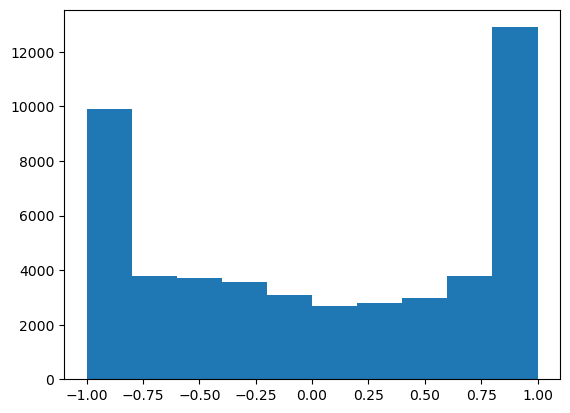

In [176]:
plt.hist(denoised_image.flatten()) # x0_reconstructed

(array([2.9500e+02, 3.8060e+03, 1.7294e+04, 2.0226e+04, 6.8030e+03,
        6.2800e+02, 8.1000e+01, 1.4000e+01, 3.0000e+00, 2.0000e+00]),
 array([-3.71876931, -2.53953576, -1.36030233, -0.18106887,  0.99816459,
         2.1773982 ,  3.35663152,  4.53586483,  5.71509838,  6.89433193,
         8.07356548]),
 <BarContainer object of 10 artists>)

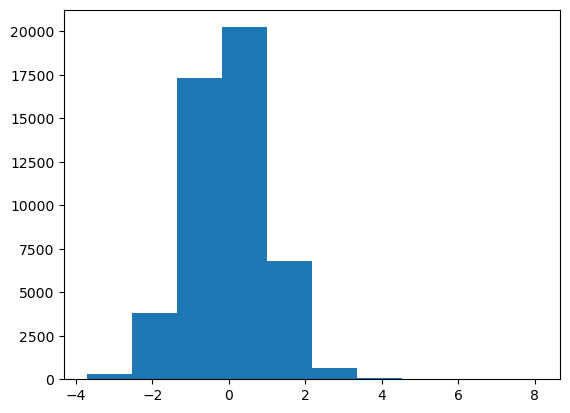

In [154]:
plt.hist(train_ds[0].flatten())

## Distribution Metrics

Series of evaluation metrics between two datasets $\mathcal S_r$ (training corpus) and $\mathcal S_f$ (generated images) respectively. Idea is to use N samples from each learned distribution and rate model on some kind of distribution distance metric. 

In [ ]:
vae_exp_id = "VAE_August05_08:23"
vae_log_pth = "trial_log.json"
with open(os.path.join("experiments", vae_exp_id, vae_log_pth), 'r') as file:
    vae_log = json.load(file)

vae_log.keys()
vae = tru.load_model_from_ckpt("best-ckpt.pt", vae_log['model_config'], vae_exp_id)

In [137]:
def compute_statistics(dataloader, num_samples, encoder):
    encoder.eval()
    features = []
    num_batches = num_samples // dataloader.batch_size + 1
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            print(f"batch {batch_idx}/{num_batches}")
            if batch_idx >= num_batches:
                break
            mu, sigma = encoder(batch)
            features.append(mu.view(mu.size(0), -1))  # Flatten each feature map
        all_features = torch.cat(features, dim=0)
        N, D = all_features.shape # combined into one huge num_samples x feature_size matrix
        assert N == num_batches*dataloader.batch_size, "Matrix dimensions do not match"
        mean = all_features.mean(dim=0)
        covariance = torch.mm((all_features - mean).T, (all_features - mean)) / (N-1) # feature_size by feature_size
    return mean, covariance, all_features

In [132]:
model_mean, model_covariance, all_features = compute_statistics(model_loader, 256, vae.encoder)

NameError: name 'vae' is not defined

In [164]:
model_covariance.shape

torch.Size([6144, 6144])

In [172]:
eps = 5
torch.cholesky(eps*torch.eye(6144, device=device), upper=False)

tensor([[2.2361, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 2.2361, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 2.2361,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 2.2361, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 2.2361, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 2.2361]],
       device='cuda:0')

In [150]:
meana = all_features.mean(dim=0)

In [152]:
(all_features - meana).shape

torch.Size([768, 6144])

In [127]:
data_covariance.T == data_covariance

tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]], device='cuda:0')

In [ ]:
# npcov = np.cov(all_features.numpy(), rowvars=False)
#np.isclose(npcov, covariance.detach().numpy()).all()

In [115]:
test_dl = DataLoader(test_ds, shuffle=True, batch_size = model_loader.batch_size)

In [167]:
data_mean, data_covariance, data_features = compute_statistics(test_dl, 1000, vae.encoder)

batch 0/4
batch 1/4
batch 2/4
batch 3/4
batch 4/4


Frechet Code copied and modified from pytorch-fid library [source code](https://github.com/mseitzer/pytorch-fid/blob/master/src/pytorch_fid/fid_score.py)

In [144]:
model_covariance > 0

tensor([[ True, False,  True,  ...,  True,  True, False],
        [False,  True, False,  ..., False, False,  True],
        [ True, False,  True,  ..., False, False, False],
        ...,
        [ True, False, False,  ...,  True,  True, False],
        [ True, False, False,  ...,  True,  True, False],
        [False,  True, False,  ..., False, False,  True]], device='cuda:0')

In [131]:
model_covariance.shape

torch.Size([6144, 6144])

In [143]:
mat = data_covariance @ model_covariance
torch.linalg.cholesky(mat + torch.eye(6144, device=device)).to(torch.float32)

_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 471 is not positive-definite).

##### FID:

- [Frechet Inception Distance](https://en.wikipedia.org/wiki/Fr%C3%A9chet_inception_distance)
- Implementation inspired by [pytorch-frechet github](https://github.com/hukkelas/pytorch-frechet-inception-distance/blob/master/fid.py)



In [123]:
def frechet_distance(dl1, dl2, encoder, num_samples):
    """
    Compute the Frechet Inception Distance (FID) between two datasets.

    Parameters:
    - dl1: A dataloader type iterator with N images.
    - dl2: A dataloader type iterator with M images.
    - encoder: A PyTorch nn.Module that outputs latent representations.
    - num_samples want drawn from distribution to compute FID

    Returns:
    - FID score as a float.
    """
    mean1, cov1, features1 = compute_statistics(dl1, num_samples, encoder)
    mean2, cov2, features2 = compute_statistics(dl2, num_samples, encoder)
    
    # Compute FID score
    mean_diff = torch.norm(mean1 - mean2).item()
    
    # Compute covariance matrix term
    cov_mean = (cov1 + cov2) / 2
    cov_sqrt, _ = torch.linalg.cholesky(cov1 @ cov2).to(torch.float32)
    
    fid_score = mean_diff**2 + torch.trace(cov1 + cov2 - 2 * cov_sqrt).item()
    return fid_score


In [130]:
np.linalg.eigvals(data_covariance.detach().cpu())

array([6.1020929e+02, 7.0041771e+01, 4.5053478e+01, ..., 5.2194338e-08,
       5.2091185e-08, 5.2340226e-08], dtype=float32)

In [124]:
frechet_distance(model_loader, test_dl, vae.encoder, 1000)

  0%|          | 0/50 [00:00<?, ?it/s]

batch 0/4


  0%|          | 0/50 [00:00<?, ?it/s]

batch 1/4


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

batch 3/4


  0%|          | 0/50 [00:00<?, ?it/s]

batch 4/4
batch 0/4
batch 1/4
batch 2/4
batch 3/4
batch 4/4


_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 3 is not positive-definite).

/home/jovyan/Samarth/2024/climsim_data_utils.py:1267: RuntimeWarning: divide by zero encountered in divide
  r_squared = 1 - sq_diff.sum(axis = 0)/tss_time.sum(axis = 0) # sum over time
/home/jovyan/Samarth/2024/climsim_data_utils.py:1267: RuntimeWarning: divide by zero encountered in divide
  r_squared = 1 - sq_diff.sum(axis = 0)/tss_time.sum(axis = 0) # sum over time


In [26]:
dutils.model_names

['fake_model', 'fake_model_2']

In [27]:
dutils.metrics_var_scoring['fake_model']

,MAE,RMSE,R2
variable,,,
ptend_t,0.133498,0.165918,0.87188
ptend_q0001,0.117729,0.146369,-inf
cam_out_NETSW,0.334654,0.41666,-inf
cam_out_FLWDS,0.160149,0.199164,0.999664
cam_out_PRECSC,0.161144,0.200279,-inf
cam_out_PRECC,1.51049,1.877517,-inf
cam_out_SOLS,0.158699,0.197494,-inf
cam_out_SOLL,0.171769,0.214642,-inf
cam_out_SOLSD,0.130798,0.162638,-inf


In [31]:
dutils.metrics_var_scoring['fake_model_2']

,MAE,RMSE,R2
variable,,,
ptend_t,53.524392,66.504104,-20675.23643
ptend_q0001,47.195209,58.636937,-inf
cam_out_NETSW,133.711817,165.237406,-inf
cam_out_FLWDS,62.48986,77.847823,-48.521115
cam_out_PRECSC,64.595863,80.611717,-inf
cam_out_PRECC,615.071302,760.312131,-inf
cam_out_SOLS,63.500213,79.138954,-inf
cam_out_SOLL,68.836698,85.51523,-inf
cam_out_SOLSD,52.464927,65.637407,-inf


In [28]:
dutils.metrics_idx_scoring['fake_model']

,MAE,RMSE,R2
output_idx,,,
0,0.000367,0.000456,0.96964
1,0.000656,0.000818,0.995107
2,0.001162,0.001447,0.986604
3,0.002043,0.002541,0.975119
4,0.003476,0.004299,0.967756
...,...,...,...
123,1.51049,1.877517,-inf
124,0.158699,0.197494,-inf
125,0.171769,0.214642,-inf
